# FX forwards and covered interest parity

Price a future currency exchange with dated domestic and foreign cash flows.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

An FX forward fixes the exchange rate for a future currency exchange. To keep signs visible, spot and strike are quoted as USD per EUR, and the position receives one EUR and pays $K$ USD at maturity.

Under zero basis and compatible collateral assumptions,

$$F=S\frac{D_{EUR}}{D_{USD}},\qquad PV_{USD}=S D_{EUR}-K D_{USD}.$$

The exercise uses spot 1.10 USD/EUR, the constructed USD curve and an illustrative flat continuously compounded EUR rate of 2.5%. At the fair forward, discounted payments cancel. Strikes 0.01 below and above fair value expose the sign of a long-EUR forward. A one-to-ten-year table connects the interest-rate difference to forward points.

Forward points are quoted in $10^{-4}$ USD/EUR in this notebook, so a point equals 0.0001 in the outright exchange rate. The strike is not an expected future spot forecast: it is the rate implied by the chosen no-basis discount factors and replication assumptions.

The numerical parity identity does not establish an executable arbitrage. Observed forward prices can also reflect collateral, funding, balance-sheet costs, bid/ask and currency basis. Those inputs are not supplied here. The [BIS discussion of covered interest parity](https://www.bis.org/publications/qr-201609/covered-interest-parity-lost-understanding-cross-currency-basis) motivates treating zero basis as an assumption rather than an observed market fact.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from research.pricing import fx_forward
spot=1.10
with valuation_date():
    discount,_,_=curves()
    rows=[]
    for year in range(1,11):
        date=CAL.advance(DATE,ql.Period(year,ql.Years))
        t=ql.Actual365Fixed().yearFraction(DATE,date)
        usd,eur=discount.discount(date),np.exp(-.025*t)
        forward=fx_forward(spot,usd,eur)
        rows.append({'years':year,'USD_discount':usd,'EUR_discount':eur,'forward_USD_per_EUR':forward,'forward_points':(forward-spot)*1e4,'fair_PV':spot*eur-forward*usd})
fx=pd.DataFrame(rows)
assert fx.fair_PV.abs().max()<1e-12
base=fx.iloc[0]
strikes=pd.DataFrame([{'strike':base.forward_USD_per_EUR+b,'long_EUR_PV_USD':spot*base.EUR_discount-(base.forward_USD_per_EUR+b)*base.USD_discount} for b in [-.01,0,.01]])
assert strikes.iloc[0].long_EUR_PV_USD>0>strikes.iloc[2].long_EUR_PV_USD
display(fx.round(6));display(strikes.round(6))

,years,USD_discount,EUR_discount,forward_USD_per_EUR,forward_points,fair_PV
0,1,0.962902,0.975310,1.114175,141.750791,0.0
1,2,0.928934,0.951164,1.126324,263.235578,0.0
2,3,0.897902,0.927553,1.136325,363.245222,0.0
3,4,0.868158,0.904713,1.146318,463.175499,0.0
4,5,0.840278,0.882436,1.155189,551.885951,0.0
5,6,0.812447,0.860590,1.165183,651.828656,0.0
6,7,0.785953,0.839342,1.174722,747.219158,0.0
7,8,0.759988,0.818619,1.184862,848.615682,0.0
8,9,0.734911,0.798297,1.194875,948.754708,0.0
9,10,0.711023,0.778641,1.204610,1046.098226,-0.0


,strike,long_EUR_PV_USD
0,1.104175,0.009629
1,1.114175,0.000000
2,1.124175,-0.009629


## Economic relationship

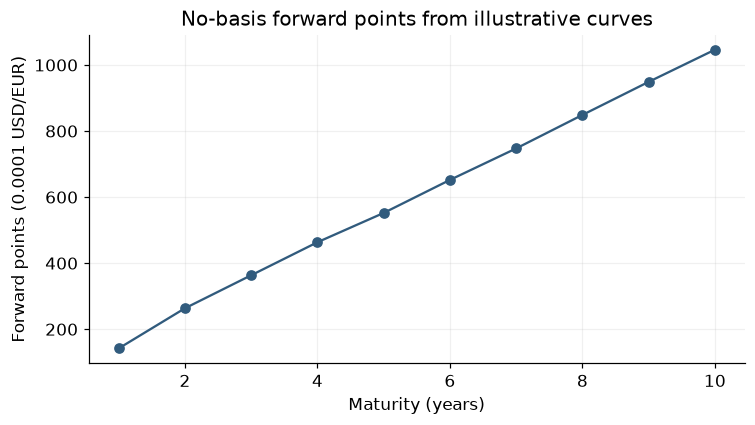

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
ax.plot(fx.years,fx.forward_points,marker='o',color='#315b7d')
ax.set(xlabel='Maturity (years)',ylabel='Forward points (0.0001 USD/EUR)',title='No-basis forward points from illustrative curves')
fig.tight_layout();plt.show()

## Interpretation

All fair forwards have zero discounted PV under the stated no-basis assumptions. A lower agreed USD strike benefits a long-EUR forward; forward points are not a forecast of the future spot rate.